1. Import Library
Mengimpor seluruh library yang akan digunakan selama proses machine learning.

In [1]:
# Mengimpor library yang dibutuhkan:
# - pandas: manipulasi dan analisis data tabular
# - numpy: komputasi numerik (array, matriks)
# - matplotlib: membuat grafik dan visualisasi
# - train_test_split: membagi data menjadi training dan testing
# - LabelEncoder: mengubah data kategorikal (teks) menjadi angka
# - StandardScaler: menstandarkan skala fitur agar mean=0, std=1
# - LogisticRegression: model klasifikasi linear (baseline)
# - DecisionTreeClassifier: model klasifikasi berbasis pohon keputusan
# - RandomForestClassifier: ensemble dari banyak Decision Tree (Bagging)
# - XGBClassifier: model Gradient Boosting yang membangun pohon secara berurutan
# - Metrik evaluasi: accuracy, precision, recall, f1, confusion matrix, ROC/AUC

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

2. Load Dataset
Membaca dataset ke dalam DataFrame Pandas.

In [2]:
# Membaca file CSV dataset ke dalam DataFrame
# Dataset berisi 129.880 baris data survei kepuasan penumpang maskapai

df = pd.read_csv("../dataset/Airline_customer_satisfaction.csv")

3. Menampilkan Data Awal
Memastikan dataset berhasil dimuat dan melihat 5 data pertama.

In [3]:
# Menampilkan 5 baris pertama data untuk melihat gambaran awal dataset

df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


4. Mengetahui Ukuran Dataset

In [4]:
# Menampilkan jumlah baris dan kolom dataset (rows, columns)

df.shape

(129880, 22)

5. Melihat Informasi Dataset

In [5]:
# Menampilkan informasi tipe data setiap kolom dan jumlah non-null values
# Berguna untuk mendeteksi kolom yang memiliki missing value

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

6. Statistik Deskriptif

In [6]:
# Menampilkan statistik deskriptif (mean, std, min, max, quartile)
# untuk semua kolom numerik

df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


7. Nama Kolom

In [7]:
# Menampilkan daftar nama semua kolom dalam dataset

df.columns

Index(['satisfaction', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient',
       'Food and drink', 'Gate location', 'Inflight wifi service',
       'Inflight entertainment', 'Online support', 'Ease of Online booking',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')

8. Cek Missing Value

In [8]:
# Mengecek jumlah missing value (data kosong) di setiap kolom
# Kolom dengan nilai > 0 perlu ditangani sebelum modeling

df.isnull().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

9. Cek Data Duplikat

In [9]:
# Mengecek jumlah data duplikat dalam dataset
# Hasil 0 berarti tidak ada baris yang sama persis

df.duplicated().sum()

0

10. Distribusi Target

In [10]:
# Menghitung jumlah data per kategori target (satisfied vs dissatisfied)

df["satisfaction"].value_counts()

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

In [11]:
# Menghitung persentase distribusi target
# Berguna untuk mengetahui apakah data seimbang atau tidak (imbalanced)

(df["satisfaction"].value_counts(normalize=True) * 100).round(2)

satisfaction
satisfied       54.73
dissatisfied    45.27
Name: proportion, dtype: float64

CLEANING
11. Mengatasi Missing Value

In [12]:
# Mengisi missing value pada kolom 'Arrival Delay in Minutes' dengan MEDIAN
# Alasan pakai median (bukan mean): kolom delay bersifat right-skewed,
# sehingga median lebih tahan terhadap nilai ekstrem (outlier)

df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
    df["Arrival Delay in Minutes"].median()
)

12. Verifikasi Missing Value

In [13]:
# Verifikasi ulang: memastikan semua missing value sudah berhasil diisi
# Semua kolom harus menunjukkan 0

df.isnull().sum()

satisfaction                         0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

13. Verifikasi Jumlah Data

In [14]:
# Mengecek ulang jumlah baris dan kolom setelah cleaning
# Memastikan tidak ada data yang hilang saat proses cleaning

df.shape

(129880, 22)

Exploratory Data Analysis (EDA)

14. Distribusi Kepuasan Penumpang

Tujuan

Mengetahui jumlah penumpang yang puas dan tidak puas.

Deteksi Outlier

Tujuan

Memeriksa distribusi data numerik dan mendeteksi keberadaan outlier.
Outlier tidak dihapus karena nilainya masih wajar dalam konteks penerbangan.

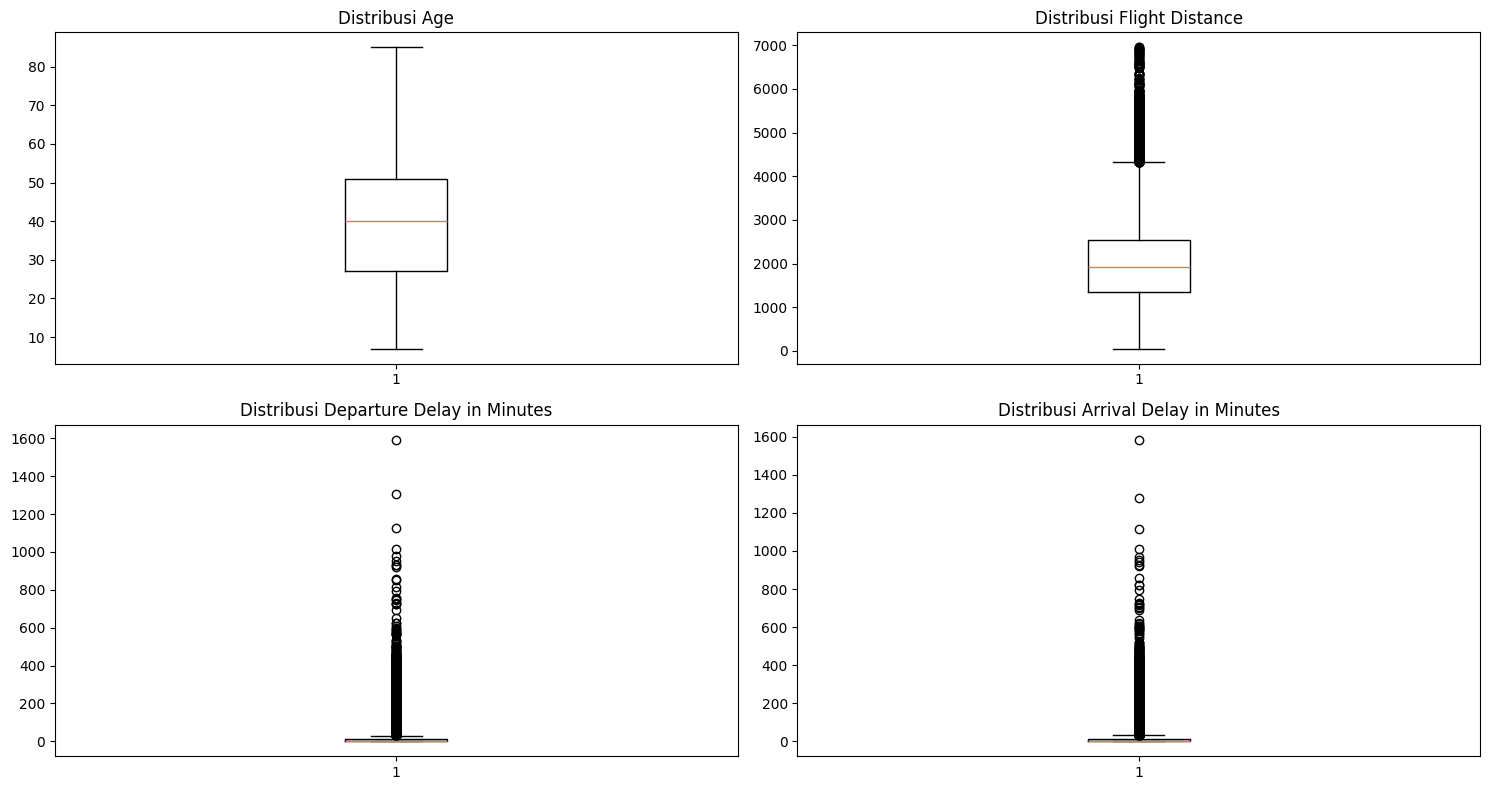

In [15]:
# Membuat boxplot untuk mendeteksi outlier pada kolom numerik
# Boxplot menunjukkan distribusi data: median, Q1, Q3, dan titik-titik outlier
# Outlier pada delay TIDAK dihapus karena masih wajar secara konteks penerbangan

kolom_numerik = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

plt.figure(figsize=(15, 8))
for i, col in enumerate(kolom_numerik):
    plt.subplot(2, 2, i+1)
    plt.boxplot(df[col].dropna())
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

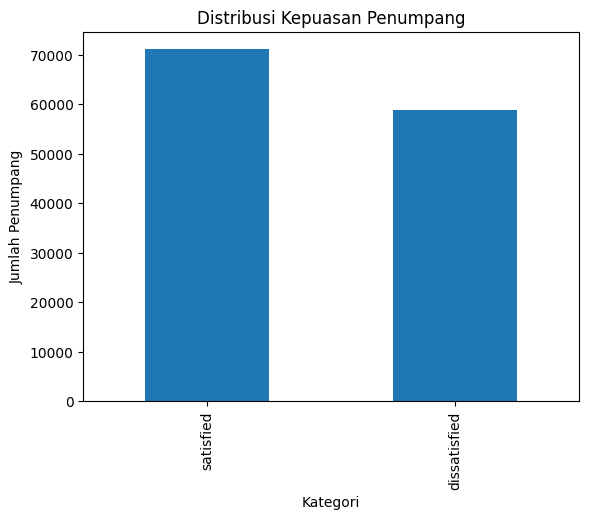

In [16]:
# Visualisasi distribusi target (satisfied vs dissatisfied) dalam bar chart
# Untuk melihat perbandingan jumlah penumpang puas vs tidak puas

df["satisfaction"].value_counts().plot(kind="bar")

plt.title("Distribusi Kepuasan Penumpang")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Penumpang")

plt.show()

15. Distribusi Jenis Pelanggan

Tujuan

Mengetahui proporsi pelanggan loyal dan pelanggan baru.

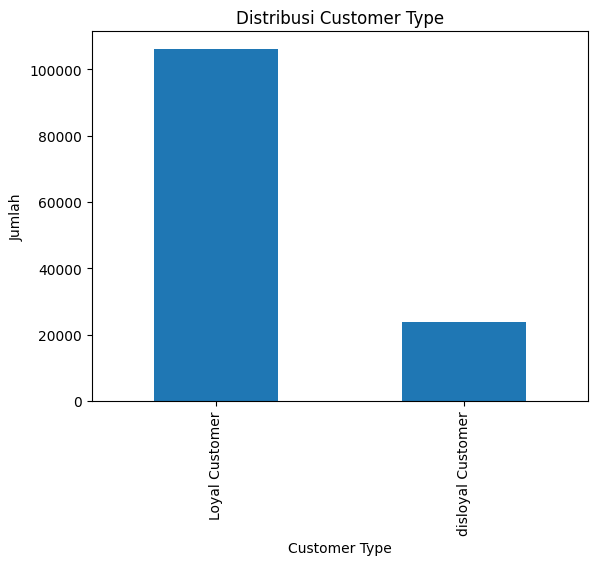

In [17]:
# Visualisasi distribusi tipe pelanggan (Loyal vs Disloyal Customer)

df["Customer Type"].value_counts().plot(kind="bar")

plt.title("Distribusi Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Jumlah")

plt.show()

16. Distribusi Kelas Penerbangan

Tujuan

Mengetahui jumlah penumpang pada setiap kelas penerbangan.

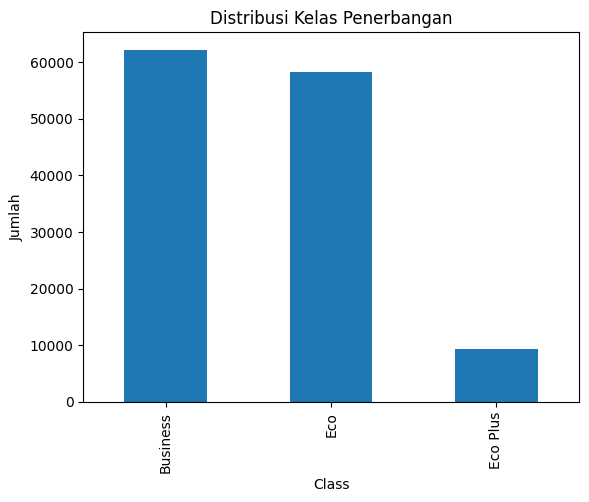

In [18]:
# Visualisasi distribusi kelas penerbangan (Business, Eco, Eco Plus)

df["Class"].value_counts().plot(kind="bar")

plt.title("Distribusi Kelas Penerbangan")
plt.xlabel("Class")
plt.ylabel("Jumlah")

plt.show()

17. Distribusi Jenis Perjalanan

Tujuan

Mengetahui proporsi perjalanan bisnis dan perjalanan pribadi.

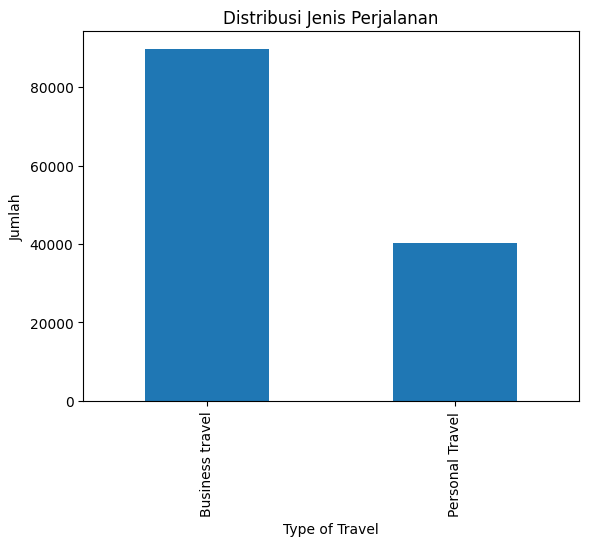

In [19]:
# Visualisasi distribusi jenis perjalanan (Business travel vs Personal Travel)

df["Type of Travel"].value_counts().plot(kind="bar")

plt.title("Distribusi Jenis Perjalanan")
plt.xlabel("Type of Travel")
plt.ylabel("Jumlah")

plt.show()

18. Distribusi Umur Penumpang

Tujuan

Melihat sebaran umur penumpang.

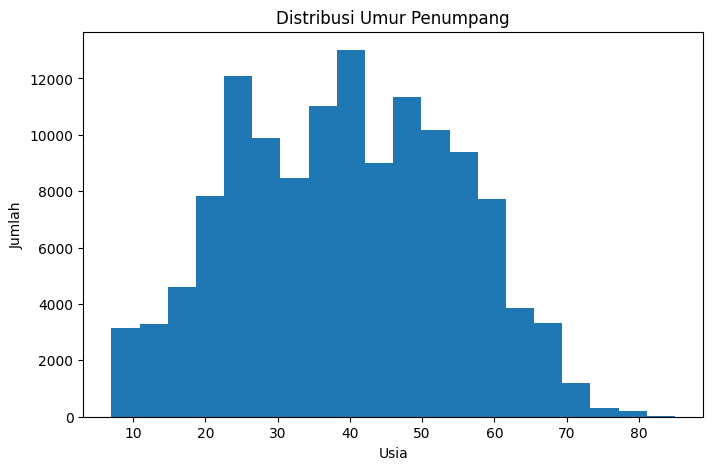

In [20]:
# Histogram distribusi umur penumpang
# Untuk melihat rentang usia penumpang yang paling banyak

plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Distribusi Umur Penumpang")
plt.xlabel("Usia")
plt.ylabel("Jumlah")

plt.show()

19. Distribusi Jarak Penerbangan

Tujuan

Melihat sebaran jarak penerbangan yang ditempuh penumpang.

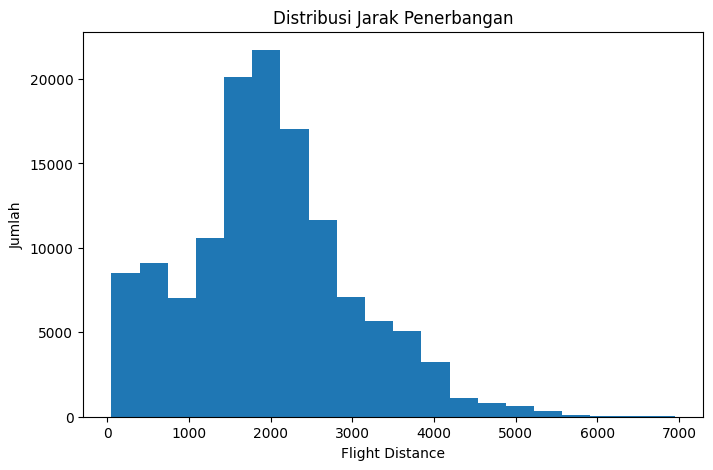

In [21]:
# Histogram distribusi jarak penerbangan
# Untuk melihat pola jarak yang paling sering ditempuh penumpang

plt.figure(figsize=(8,5))

plt.hist(df["Flight Distance"], bins=20)

plt.title("Distribusi Jarak Penerbangan")
plt.xlabel("Flight Distance")
plt.ylabel("Jumlah")

plt.show()

20. Distribusi Keterlambatan Keberangkatan

Tujuan

Melihat distribusi keterlambatan keberangkatan.

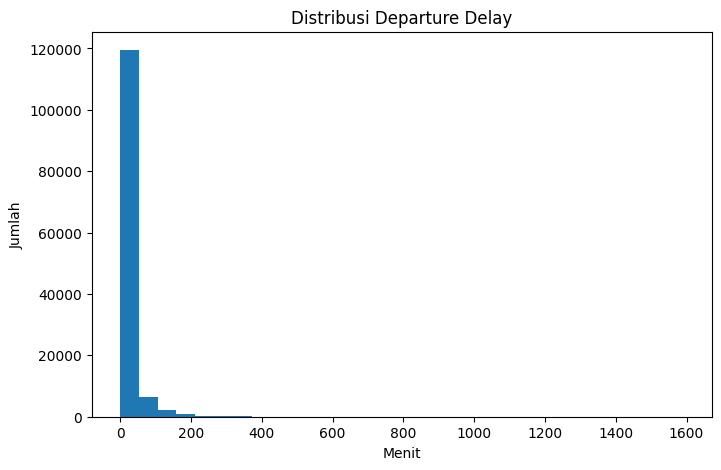

In [22]:
# Histogram distribusi delay keberangkatan (dalam menit)
# Distribusi sangat right-skewed: mayoritas 0, sedikit yang delay panjang

plt.figure(figsize=(8,5))

plt.hist(df["Departure Delay in Minutes"], bins=30)

plt.title("Distribusi Departure Delay")
plt.xlabel("Menit")
plt.ylabel("Jumlah")

plt.show()

21. Distribusi Keterlambatan Kedatangan

Tujuan

Melihat distribusi keterlambatan kedatangan.

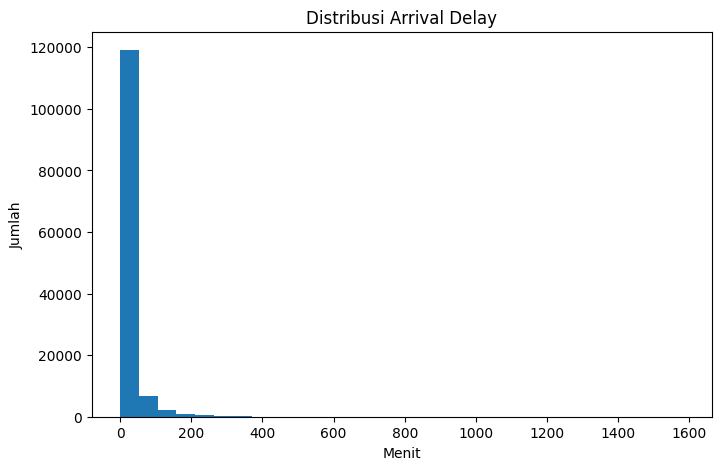

In [23]:
# Histogram distribusi delay kedatangan (dalam menit)
# Pola serupa dengan departure delay: mayoritas tepat waktu

plt.figure(figsize=(8,5))

plt.hist(df["Arrival Delay in Minutes"], bins=30)

plt.title("Distribusi Arrival Delay")
plt.xlabel("Menit")
plt.ylabel("Jumlah")

plt.show()

22. Korelasi Antar Fitur Numerik

Tujuan

Mengetahui hubungan antar fitur numerik.

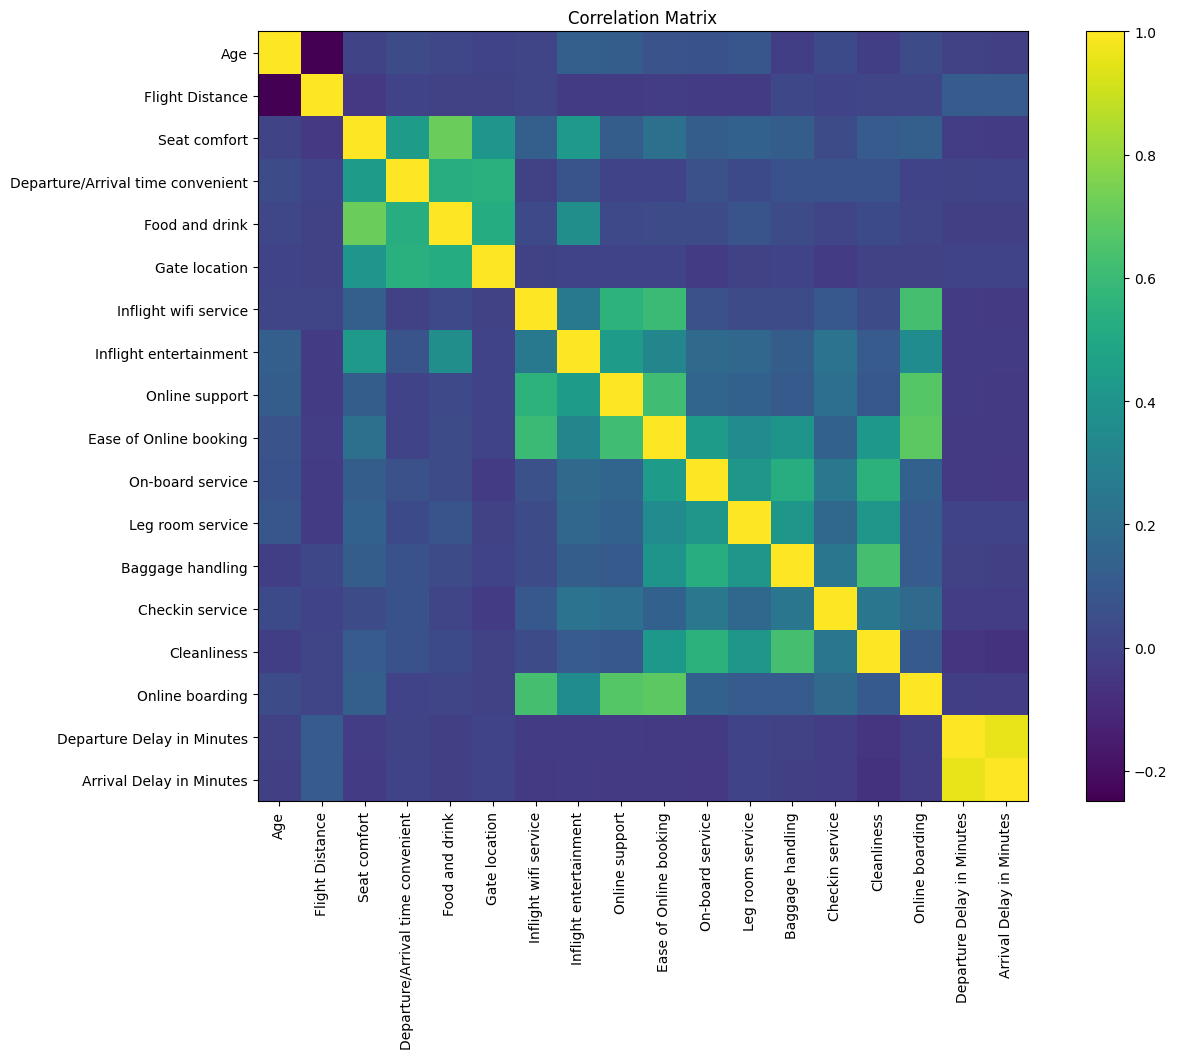

In [24]:
# Membuat heatmap correlation matrix untuk melihat hubungan antar fitur numerik
# Nilai mendekati 1 = korelasi positif kuat, mendekati -1 = korelasi negatif kuat
# Berguna sebagai indikasi awal fitur mana yang paling berpengaruh

plt.figure(figsize=(15,10))

correlation = df.corr(numeric_only=True)

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

Data Preprocessing



23. Encoding Data Kategorikal
Tujuan

Mengubah data bertipe teks (string) menjadi angka agar dapat diproses oleh algoritma machine learning.

In [25]:
# Mengubah kolom kategorikal (teks) menjadi angka menggunakan LabelEncoder
# Kolom yang di-encode: satisfaction, Customer Type, Type of Travel, Class
# Encoder disimpan dalam dictionary agar bisa dipakai ulang saat deploy (Streamlit)

categorical_columns = [
    "satisfaction",
    "Customer Type",
    "Type of Travel",
    "Class"
]

encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    encoders[column] = encoder

df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1,0,65,1,1,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1,0,47,1,0,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1,0,15,1,1,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1,0,60,1,1,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1,0,70,1,1,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [26]:
# Verifikasi hasil encoding — memastikan data sudah berubah menjadi numerik

import joblib

joblib.dump(
    encoders,
    "../model/label_encoders.pkl"
)

print("Encoder berhasil disimpan.")

Encoder berhasil disimpan.


24. Memastikan Encoding Berhasil

In [27]:
# Memisahkan fitur (X) dan target (y)
# X = semua kolom kecuali 'satisfaction' (fitur input)
# y = kolom 'satisfaction' saja (label yang ingin diprediksi)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  int32  
 1   Customer Type                      129880 non-null  int32  
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  int32  
 4   Class                              129880 non-null  int32  
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

25. Memisahkan Feature dan Target

In [28]:
# Membagi data menjadi 80% training dan 20% testing
# stratify=y memastikan proporsi satisfied/dissatisfied tetap seimbang di kedua set
# random_state=42 agar hasil split bisa direproduksi (konsisten setiap kali dijalankan)

X = df.drop("satisfaction", axis=1)

y = df["satisfaction"]

26. Melihat Ukuran Feature dan Target
Tujuan

Memastikan pemisahan data berhasil dilakukan.

In [29]:
# Menampilkan jumlah data training dan testing setelah split
# Training: 103.904 baris | Testing: 25.976 baris

print("Feature :", X.shape)

print("Target :", y.shape)

Feature : (129880, 21)
Target : (129880,)


27. Data Splitting

In [30]:
# Feature Scaling menggunakan StandardScaler (z-score normalization)
# Hanya untuk Logistic Regression karena model linear sensitif terhadap skala fitur
# fit_transform pada training: menghitung mean & std, lalu transformasi
# transform pada testing: menggunakan mean & std dari training (mencegah data leakage)
# Model tree-based (DT, RF, XGBoost) TIDAK perlu scaling

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

28. Verifikasi

In [31]:
print("X Train :", X_train.shape)

print("X Test :", X_test.shape)

print("y Train :", y_train.shape)

print("y Test :", y_test.shape)

X Train : (103904, 21)
X Test : (25976, 21)
y Train : (103904,)
y Test : (25976,)


29. Feature Scaling

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [33]:
# Melakukan prediksi pada data testing menggunakan model Logistic Regression
# Menggunakan data testing yang sudah di-scale (X_test_scaled)

import joblib

joblib.dump(
    scaler,
    "../model/standard_scaler.pkl"
)

print("Standard Scaler berhasil disimpan.")

Standard Scaler berhasil disimpan.


Training Model

1. Training Logistic Regression

30. Membuat dan melatih model

In [34]:
# Menampilkan classification report lengkap (precision, recall, f1 per kelas)
# Berguna untuk melihat performa model pada masing-masing kelas (0 dan 1)

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

31. Prediksi

In [35]:
# Menampilkan confusion matrix model Logistic Regression
# Format: [[True Negative, False Positive], [False Negative, True Positive]]
# TN = benar prediksi 'tidak puas', TP = benar prediksi 'puas'
# FP = salah prediksi 'puas' (padahal tidak), FN = salah prediksi 'tidak puas' (padahal puas)

y_pred_logistic = logistic_model.predict(X_test_scaled)

32. Evaluasi Logistic Regression

In [36]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

logistic_precision = precision_score(y_test, y_pred_logistic)

logistic_recall = recall_score(y_test, y_pred_logistic)

logistic_f1 = f1_score(y_test, y_pred_logistic)

print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall    :", logistic_recall)
print("F1 Score  :", logistic_f1)

Accuracy : 0.8289190021558361
Precision: 0.8445321864203624
Recall    : 0.8425124850531054
F1 Score  : 0.8435211267605633


33. Classification Report

In [37]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11759
           1       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



34. Confusion Matrix

In [38]:
cm = confusion_matrix(y_test, y_pred_logistic)

print(cm)

[[ 9554  2205]
 [ 2239 11978]]


2. Training Decision Tree

35. Membuat Model

In [39]:
# Classification report lengkap untuk Decision Tree

decision_tree_model = DecisionTreeClassifier(random_state=42)

decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

36. Prediksi

In [40]:
# Confusion matrix model Decision Tree

y_pred_decision_tree = decision_tree_model.predict(X_test)

37. Evaluasi

In [41]:
decision_tree_accuracy = accuracy_score(y_test, y_pred_decision_tree)

decision_tree_precision = precision_score(y_test, y_pred_decision_tree)

decision_tree_recall = recall_score(y_test, y_pred_decision_tree)

decision_tree_f1 = f1_score(y_test, y_pred_decision_tree)

print("Accuracy :", decision_tree_accuracy)
print("Precision:", decision_tree_precision)
print("Recall    :", decision_tree_recall)
print("F1 Score  :", decision_tree_f1)

Accuracy : 0.9322836464428703
Precision: 0.9377371749824315
Recall    : 0.9385946402194556
F1 Score  : 0.9381657116743417


38. Classification Report

In [42]:
print(classification_report(y_test, y_pred_decision_tree))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93     11759
           1       0.94      0.94      0.94     14217

    accuracy                           0.93     25976
   macro avg       0.93      0.93      0.93     25976
weighted avg       0.93      0.93      0.93     25976



29. Confusion Matrix

In [43]:
cm = confusion_matrix(y_test, y_pred_decision_tree)

print(cm)

[[10873   886]
 [  873 13344]]


3. Training Random Forest

40. Membuat Model

In [44]:
# Classification report lengkap untuk Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

41. Prediksi

In [45]:
# Confusion matrix model Random Forest

y_pred_random_forest = random_forest_model.predict(X_test)

42. Evaluasi

In [46]:
random_forest_accuracy = accuracy_score(y_test, y_pred_random_forest)

random_forest_precision = precision_score(y_test, y_pred_random_forest)

random_forest_recall = recall_score(y_test, y_pred_random_forest)

random_forest_f1 = f1_score(y_test, y_pred_random_forest)

print("Accuracy :", random_forest_accuracy)
print("Precision:", random_forest_precision)
print("Recall    :", random_forest_recall)
print("F1 Score  :", random_forest_f1)

Accuracy : 0.9558053587927318
Precision: 0.9689271618227485
Recall    : 0.9497080959414785
F1 Score  : 0.9592213697073032


43. Classification Report

In [47]:
print(classification_report(y_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95     11759
           1       0.97      0.95      0.96     14217

    accuracy                           0.96     25976
   macro avg       0.95      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



44. Confusion Matrix

In [48]:
cm = confusion_matrix(y_test, y_pred_random_forest)

print(cm)

[[11326   433]
 [  715 13502]]


4. Training XGBoost

45. Membuat Model

In [49]:
# Melatih model XGBoost (Extreme Gradient Boosting)
# Pohon dibangun secara BERURUTAN: setiap pohon baru fokus memperbaiki
# kesalahan prediksi dari pohon sebelumnya (teknik Boosting)
# eval_metric='logloss': fungsi loss untuk klasifikasi biner

xgboost_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgboost_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

46. Prediksi

In [50]:
# Melakukan prediksi pada data testing menggunakan model XGBoost

y_pred_xgboost = xgboost_model.predict(X_test)

47. Evaluasi

In [51]:
# Menghitung metrik evaluasi model XGBoost
# XGBoost menghasilkan performa terbaik di antara keempat model

xgboost_accuracy = accuracy_score(y_test, y_pred_xgboost)

xgboost_precision = precision_score(y_test, y_pred_xgboost)

xgboost_recall = recall_score(y_test, y_pred_xgboost)

xgboost_f1 = f1_score(y_test, y_pred_xgboost)

print("Accuracy :", xgboost_accuracy)
print("Precision:", xgboost_precision)
print("Recall    :", xgboost_recall)
print("F1 Score  :", xgboost_f1)

Accuracy : 0.9573837388358485
Precision: 0.96975777554823
Recall    : 0.9518182457621158
F1 Score  : 0.9607042703489403


48. Classification Report

In [52]:
# Classification report lengkap untuk XGBoost

print(classification_report(y_test, y_pred_xgboost))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95     11759
           1       0.97      0.95      0.96     14217

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



49. Confusion Matrix

In [53]:
# Confusion matrix model XGBoost

cm = confusion_matrix(y_test, y_pred_xgboost)

print(cm)

[[11337   422]
 [  685 13532]]


Model Comparison

50. Membuat Tabel Perbandingan

In [54]:
# Membuat tabel perbandingan performa keempat model
# Mengumpulkan semua metrik (Accuracy, Precision, Recall, F1 Score)
# ke dalam satu DataFrame agar mudah dibandingkan

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        xgboost_accuracy
    ],
    "Precision": [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision,
        xgboost_precision
    ],
    "Recall": [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall,
        xgboost_recall
    ],
    "F1 Score": [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1,
        xgboost_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.828919,0.844532,0.842512,0.843521
1,Decision Tree,0.932284,0.937737,0.938595,0.938166
2,Random Forest,0.955805,0.968927,0.949708,0.959221
3,XGBoost,0.957384,0.969758,0.951818,0.960704


51. Mengurutkan Model Terbaik

In [55]:
# Mengurutkan model dari akurasi tertinggi ke terendah
# Untuk menentukan model mana yang paling unggul

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.957384,0.969758,0.951818,0.960704
2,Random Forest,0.955805,0.968927,0.949708,0.959221
1,Decision Tree,0.932284,0.937737,0.938595,0.938166
0,Logistic Regression,0.828919,0.844532,0.842512,0.843521


52. Grafik Perbandingan Accuracy

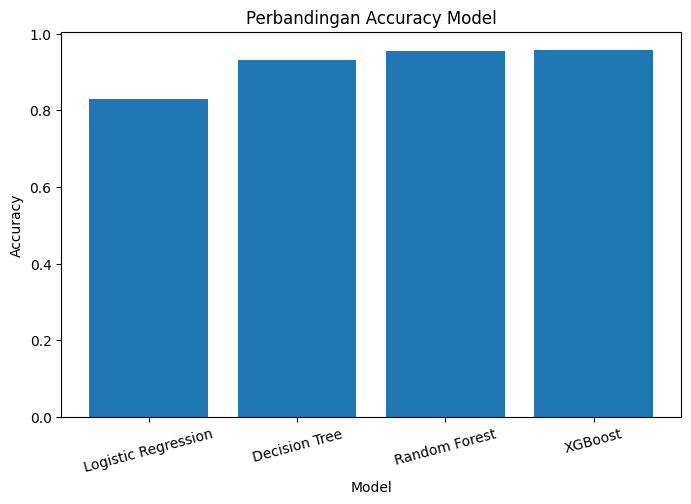

In [56]:
# Visualisasi perbandingan Accuracy keempat model dalam bar chart

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Perbandingan Accuracy Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

53. Grafik Perbandingan F1 Score

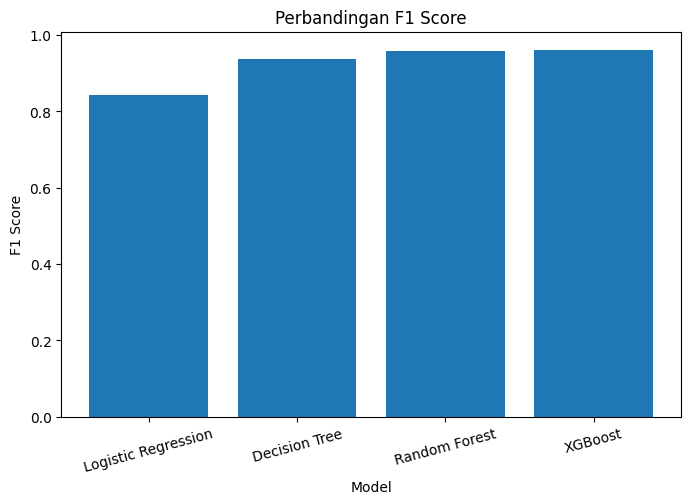

In [57]:
# Visualisasi perbandingan F1 Score keempat model dalam bar chart
# F1 Score dipilih karena merupakan metrik seimbang antara Precision dan Recall

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["F1 Score"]
)

plt.title("Perbandingan F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=15)

plt.show()

54. Grafik Accuracy

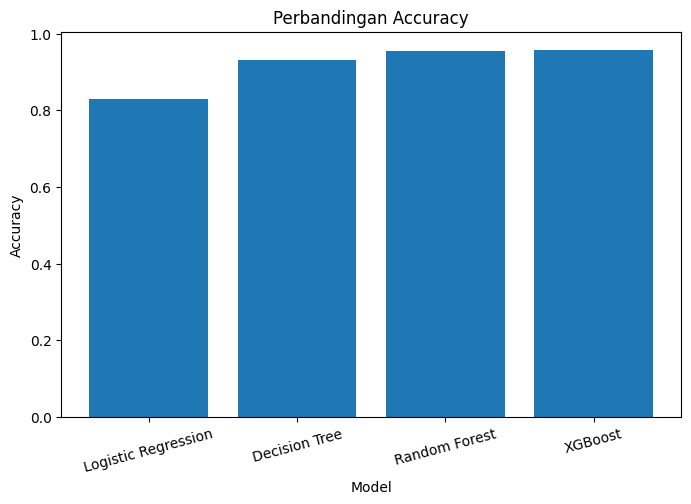

In [58]:
# Visualisasi perbandingan Accuracy (tampilan alternatif)

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Perbandingan Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

55. Grafik Precision

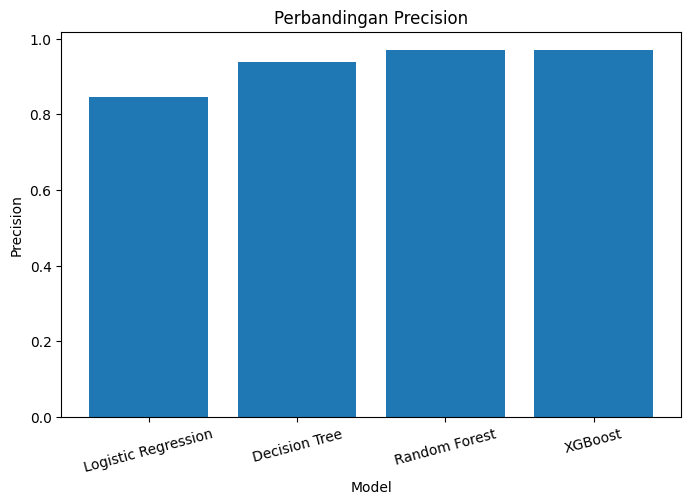

In [59]:
# Visualisasi perbandingan Precision keempat model
# Precision mengukur ketepatan prediksi positif model

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Precision"])

plt.title("Perbandingan Precision")
plt.xlabel("Model")
plt.ylabel("Precision")

plt.xticks(rotation=15)

plt.show()

56. Grafik Recall

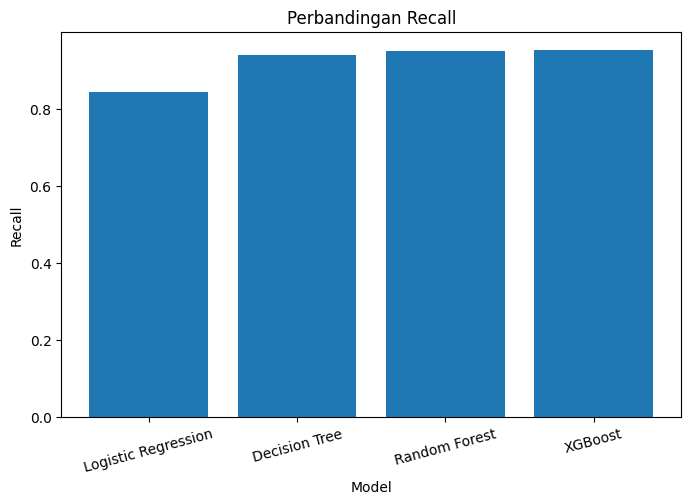

In [60]:
# Visualisasi perbandingan Recall keempat model
# Recall mengukur kemampuan model menangkap semua data positif

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Recall"])

plt.title("Perbandingan Recall")
plt.xlabel("Model")
plt.ylabel("Recall")

plt.xticks(rotation=15)

plt.show()

57. Feature Importance

In [61]:
# Menghitung Feature Importance dari model Random Forest
# Feature importance menunjukkan fitur mana yang paling berpengaruh
# terhadap keputusan prediksi model (berdasarkan seberapa sering fitur
# digunakan untuk membuat split di pohon-pohon dalam hutan)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,Inflight entertainment,0.202717
5,Seat comfort,0.140070
12,Ease of Online booking,0.077873
11,Online support,0.059079
7,Food and drink,0.045281
13,On-board service,0.044433
0,Customer Type,0.042644
14,Leg room service,0.040795
4,Flight Distance,0.039984
3,Class,0.036955


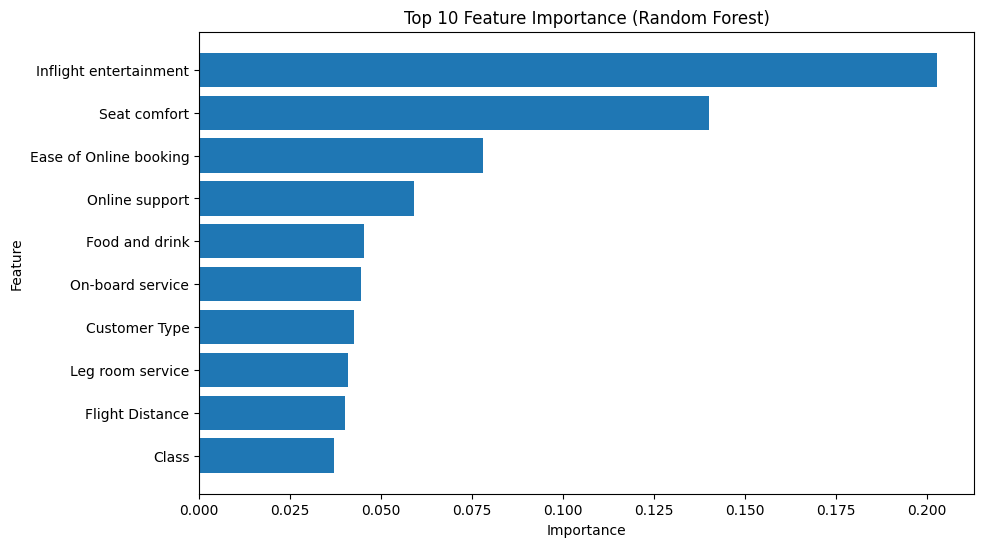

In [62]:
# Visualisasi 10 fitur paling penting (horizontal bar chart)
# Fitur teratas = paling menentukan kepuasan penumpang

top_feature = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_feature["Feature"],
    top_feature["Importance"]
)

plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

58. Conclusion

In [63]:
# Menentukan dan menampilkan model terbaik berdasarkan akurasi tertinggi

best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("Model Terbaik")
print(best_model)

Model Terbaik
Model         XGBoost
Accuracy     0.957384
Precision    0.969758
Recall       0.951818
F1 Score     0.960704
Name: 3, dtype: object


ROC Curve
Membandingkan kemampuan keempat model dalam membedakan kelas Satisfied dan Dissatisfied berdasarkan nilai AUC (Area Under Curve).

59. Menghitung Probabilitas Prediksi

In [64]:
# Menghitung probabilitas prediksi (confidence) dari setiap model
# [:, 1] mengambil probabilitas untuk kelas positif (satisfied)
# Probabilitas ini dibutuhkan untuk membuat ROC Curve

# Logistic Regression
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Decision Tree
y_prob_decision_tree = decision_tree_model.predict_proba(X_test)[:, 1]

# Random Forest
y_prob_random_forest = random_forest_model.predict_proba(X_test)[:, 1]

# XGBoost
y_prob_xgboost = xgboost_model.predict_proba(X_test)[:, 1]

60. Menghitung ROC dan AUC

In [65]:
# Menghitung ROC Curve (FPR vs TPR) dan AUC Score untuk setiap model
# ROC Curve mengukur kemampuan model membedakan kedua kelas di semua threshold
# AUC (Area Under Curve): semakin mendekati 1.0, semakin baik model memisahkan kelas

# Logistic Regression
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
auc_logistic = roc_auc_score(y_test, y_prob_logistic)

# Decision Tree
fpr_decision_tree, tpr_decision_tree, _ = roc_curve(y_test, y_prob_decision_tree)
auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)

# Random Forest
fpr_random_forest, tpr_random_forest, _ = roc_curve(y_test, y_prob_random_forest)
auc_random_forest = roc_auc_score(y_test, y_prob_random_forest)

# XGBoost
fpr_xgboost, tpr_xgboost, _ = roc_curve(y_test, y_prob_xgboost)
auc_xgboost = roc_auc_score(y_test, y_prob_xgboost)

61. Menampilkan ROC Curve Semua Model

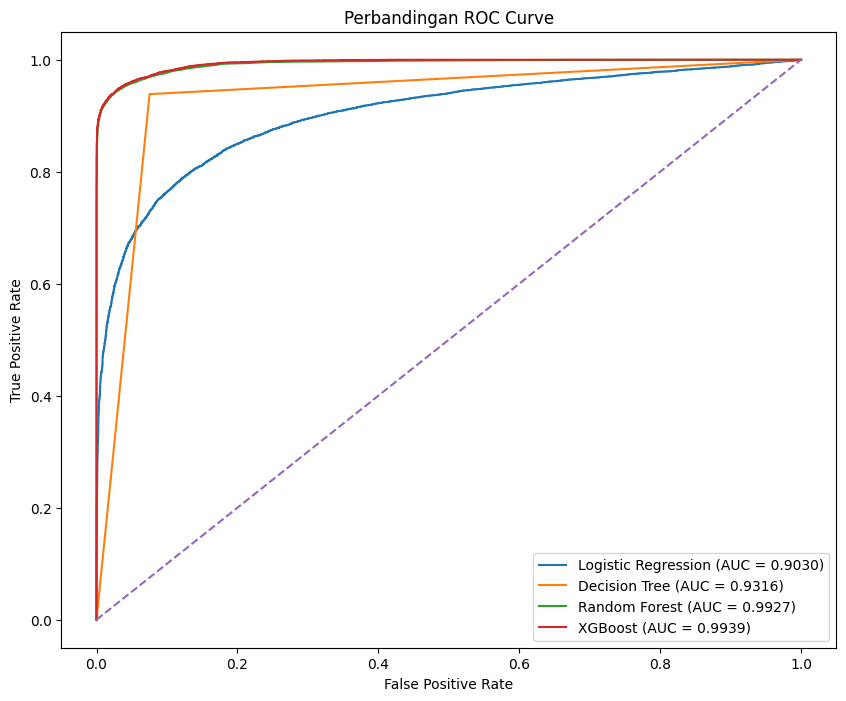

In [66]:
# Menampilkan ROC Curve keempat model dalam satu grafik
# Garis putus-putus diagonal = model acak (random classifier, AUC = 0.5)
# Semakin jauh kurva dari garis diagonal, semakin baik performa model

plt.figure(figsize=(10,8))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.4f})"
)

plt.plot(
    fpr_decision_tree,
    tpr_decision_tree,
    label=f"Decision Tree (AUC = {auc_decision_tree:.4f})"
)

plt.plot(
    fpr_random_forest,
    tpr_random_forest,
    label=f"Random Forest (AUC = {auc_random_forest:.4f})"
)

plt.plot(
    fpr_xgboost,
    tpr_xgboost,
    label=f"XGBoost (AUC = {auc_xgboost:.4f})"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Perbandingan ROC Curve")

plt.legend()

plt.show()

Cross Validation (5-Fold)

Tujuan

Membandingkan performa keempat model menggunakan 5-Fold Cross Validation
agar hasil evaluasi lebih reliable dan tidak bergantung pada satu kali split.

In [67]:
# 5-Fold Cross Validation: membagi data training menjadi 5 bagian
# Model dilatih di 4 bagian dan diuji di 1 bagian, bergantian 5 kali
# Hasilnya dirata-rata untuk mendapat estimasi performa yang lebih reliable
# StratifiedKFold memastikan proporsi kelas tetap seimbang di setiap fold
# Std (standar deviasi) kecil = model konsisten, tidak tergantung pembagian data

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': logistic_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model,
    'XGBoost': xgboost_model
}

cv_results = []

for name, model in models_cv.items():
    if name == 'Logistic Regression':
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    cv_results.append({
        'Model': name,
        'Mean Accuracy': scores.mean(),
        'Std': scores.std()
    })

    print(f'{name}')
    print(f'  Accuracy setiap fold : {scores}')
    print(f'  Rata-rata Accuracy   : {scores.mean():.4f} (+/- {scores.std():.4f})')
    print()

Logistic Regression
  Accuracy setiap fold : [0.82936336 0.83018142 0.82840094 0.82960397 0.82617902]
  Rata-rata Accuracy   : 0.8287 (+/- 0.0014)

Decision Tree
  Accuracy setiap fold : [0.93412252 0.93210144 0.93354507 0.93012848 0.93532243]
  Rata-rata Accuracy   : 0.9330 (+/- 0.0018)

Random Forest
  Accuracy setiap fold : [0.95442953 0.95346711 0.95486261 0.95404456 0.95558229]
  Rata-rata Accuracy   : 0.9545 (+/- 0.0007)

XGBoost
  Accuracy setiap fold : [0.95486261 0.95519946 0.95510322 0.95332275 0.95659288]
  Rata-rata Accuracy   : 0.9550 (+/- 0.0010)



Tabel Hasil Cross Validation

In [68]:
# Menampilkan tabel hasil Cross Validation (Mean Accuracy & Std per model)

cv_df = pd.DataFrame(cv_results)
cv_df

,Model,Mean Accuracy,Std
0,Logistic Regression,0.828746,0.001406
1,Decision Tree,0.933044,0.001789
2,Random Forest,0.954477,0.000718
3,XGBoost,0.955016,0.001041


Grafik Cross Validation

Tujuan

Memvisualisasikan perbandingan akurasi keempat model berdasarkan 5-Fold CV.

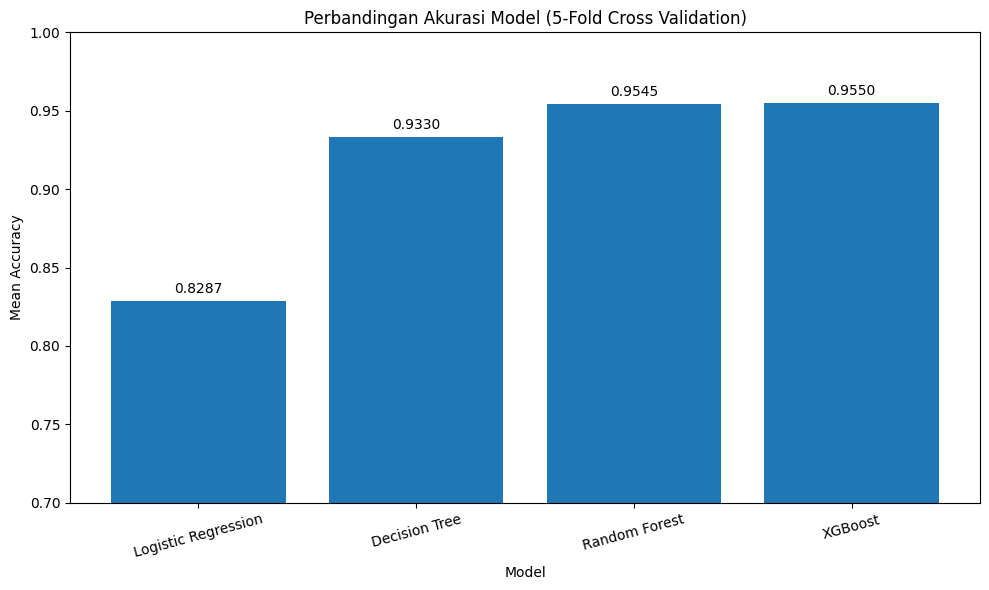

In [69]:
# Visualisasi perbandingan Mean Accuracy dari 5-Fold Cross Validation
# Angka di atas bar menunjukkan nilai akurasi rata-rata setiap model

plt.figure(figsize=(10, 6))

plt.bar(cv_df['Model'], cv_df['Mean Accuracy'])

plt.title('Perbandingan Akurasi Model (5-Fold Cross Validation)')
plt.xlabel('Model')
plt.ylabel('Mean Accuracy')

plt.ylim(0.7, 1.0)
plt.xticks(rotation=15)

for i, v in enumerate(cv_df['Mean Accuracy']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

Hyperparameter Tuning

Tujuan

Mencari kombinasi parameter terbaik untuk setiap model menggunakan RandomizedSearchCV
agar perbandingan antar model lebih fair.

In [70]:
# Hyperparameter Tuning menggunakan RandomizedSearchCV
# Mencari kombinasi parameter terbaik secara otomatis untuk setiap model
# param_grids: daftar parameter yang akan dicoba untuk setiap model
# n_iter=5: mencoba 5 kombinasi acak (lebih cepat dari GridSearchCV)
# cv=3: validasi silang 3-fold untuk setiap kombinasi
# scoring='accuracy': memilih kombinasi dengan akurasi tertinggi
# n_jobs=-1: menggunakan semua core CPU agar lebih cepat
# Hasil: best_models berisi model dengan parameter optimal untuk setiap algoritma

from sklearn.model_selection import RandomizedSearchCV

param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    'Decision Tree': {
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
}

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

best_models = {}
tuning_results = []

for name in base_models:
    print(f'Tuning {name}...')

    if name == 'Logistic Regression':
        X_tr = X_train_scaled
    else:
        X_tr = X_train

    search = RandomizedSearchCV(
        estimator=base_models[name],
        param_distributions=param_grids[name],
        n_iter=5,
        cv=3,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_tr, y_train)

    best_models[name] = search.best_estimator_

    tuning_results.append({
        'Model': name,
        'Best Score (CV)': search.best_score_,
        'Best Params': str(search.best_params_)
    })

    print(f'  Best Score : {search.best_score_:.4f}')
    print(f'  Best Params: {search.best_params_}')
    print()

Tuning Logistic Regression...
  Best Score : 0.8289
  Best Params: {'solver': 'liblinear', 'C': 0.01}

Tuning Decision Tree...
  Best Score : 0.9369
  Best Params: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 15}

Tuning Random Forest...
  Best Score : 0.9536
  Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}

Tuning XGBoost...
  Best Score : 0.9556
  Best Params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.2}



Tabel Hasil Tuning

In [71]:
# Menampilkan tabel hasil tuning: skor terbaik dan parameter optimal per model

tuning_df = pd.DataFrame(tuning_results)
tuning_df

,Model,Best Score (CV),Best Params
0,Logistic Regression,0.828871,"{'solver': 'liblinear', 'C': 0.01}"
1,Decision Tree,0.936874,"{'min_samples_split': 10, 'min_samples_leaf': ..."
2,Random Forest,0.953640,"{'n_estimators': 100, 'min_samples_split': 2, ..."
3,XGBoost,0.955555,"{'subsample': 1.0, 'n_estimators': 100, 'max_d..."


Evaluasi Model Setelah Tuning

Tujuan

Mengevaluasi ulang performa keempat model setelah parameter dioptimasi.

In [72]:
# Mengevaluasi ulang performa keempat model SETELAH hyperparameter tuning
# Membandingkan Accuracy dan ROC-AUC dari model yang sudah dioptimasi
# Logistic Regression tetap menggunakan data yang sudah di-scale

tuned_results = []

for name, model in best_models.items():
    if name == 'Logistic Regression':
        y_pred_tuned = model.predict(X_test_scaled)
        y_prob_tuned = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_tuned = model.predict(X_test)
        y_prob_tuned = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred_tuned)
    auc = roc_auc_score(y_test, y_prob_tuned)

    tuned_results.append({
        'Model': name,
        'Accuracy (Tuned)': acc,
        'ROC-AUC (Tuned)': auc
    })

    print(f'=== {name} (Tuned) ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred_tuned))
    print('-' * 50)

tuned_df = pd.DataFrame(tuned_results)
tuned_df

=== Logistic Regression (Tuned) ===
Accuracy : 0.8288
ROC-AUC  : 0.9030
              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11759
           1       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976

--------------------------------------------------
=== Decision Tree (Tuned) ===
Accuracy : 0.9399
ROC-AUC  : 0.9780
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     11759
           1       0.96      0.93      0.94     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976

--------------------------------------------------
=== Random Forest (Tuned) ===
Accuracy : 0.9558
ROC-AUC  : 0.9927
              precision    recall  f1-sc

,Model,Accuracy (Tuned),ROC-AUC (Tuned)
0,Logistic Regression,0.828842,0.902988
1,Decision Tree,0.939945,0.978044
2,Random Forest,0.955805,0.992688
3,XGBoost,0.957499,0.994022


Perbandingan Sebelum dan Sesudah Tuning

Tujuan

Membandingkan performa model sebelum dan sesudah hyperparameter tuning
untuk melihat apakah tuning memberikan peningkatan.

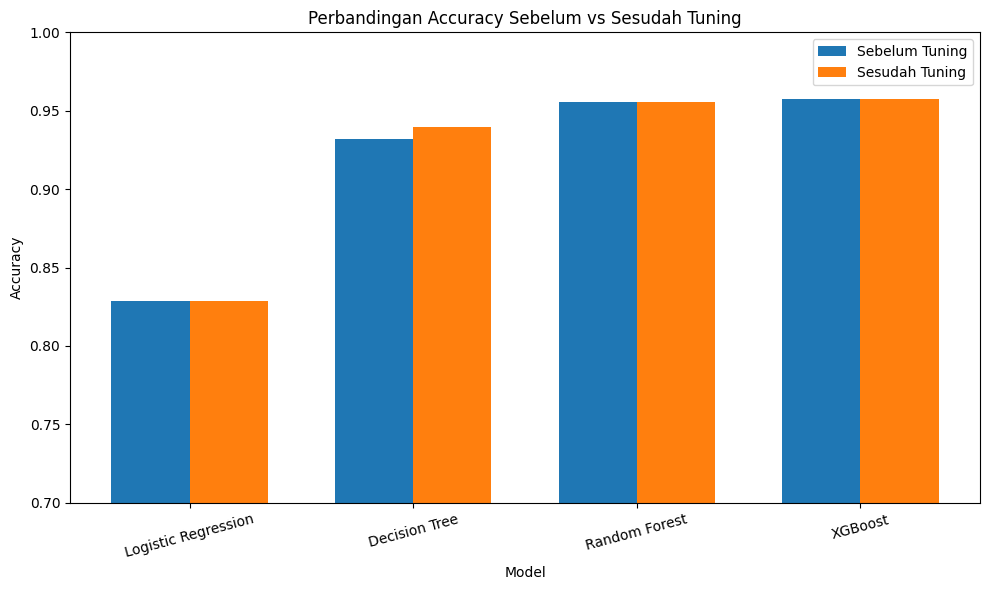

In [73]:
# Visualisasi perbandingan Accuracy SEBELUM vs SESUDAH hyperparameter tuning
# Grouped bar chart: bar kiri = sebelum tuning, bar kanan = sesudah tuning
# Untuk melihat apakah tuning memberikan peningkatan performa yang signifikan

before = comparison[['Model', 'Accuracy']].copy()
before['Kondisi'] = 'Sebelum Tuning'

after = tuned_df[['Model', 'Accuracy (Tuned)']].copy()
after = after.rename(columns={'Accuracy (Tuned)': 'Accuracy'})
after['Kondisi'] = 'Sesudah Tuning'

compare_tuning = pd.concat([before, after], ignore_index=True)

plt.figure(figsize=(10, 6))

x = np.arange(len(before))
width = 0.35

plt.bar(x - width/2, before['Accuracy'], width, label='Sebelum Tuning')
plt.bar(x + width/2, after['Accuracy'], width, label='Sesudah Tuning')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Perbandingan Accuracy Sebelum vs Sesudah Tuning')
plt.xticks(x, before['Model'], rotation=15)
plt.ylim(0.7, 1.0)
plt.legend()

plt.tight_layout()
plt.show()

## Save Model

In [74]:
# Mengimpor library joblib untuk menyimpan (serialisasi) model ke file .pkl

import joblib

In [75]:
# Menyimpan model Logistic Regression (versi tuned) ke file .pkl
# File ini akan di-load oleh aplikasi Streamlit untuk melakukan prediksi

joblib.dump(
    best_models['Logistic Regression'],
    "../model/logistic_regression.pkl"
)

print("Logistic Regression (Tuned) berhasil disimpan.")

Logistic Regression (Tuned) berhasil disimpan.


In [76]:
# Menyimpan model Decision Tree (versi tuned) ke file .pkl

joblib.dump(
    best_models['Decision Tree'],
    "../model/decision_tree.pkl"
)

print("Decision Tree (Tuned) berhasil disimpan.")

Decision Tree (Tuned) berhasil disimpan.


In [77]:
# Menyimpan model Random Forest (versi tuned) ke file .pkl

joblib.dump(
    best_models['Random Forest'],
    "../model/random_forest.pkl"
)

print("Random Forest (Tuned) berhasil disimpan.")

Random Forest (Tuned) berhasil disimpan.


In [78]:
# Menyimpan model XGBoost (versi tuned) ke file .pkl

joblib.dump(
    best_models['XGBoost'],
    "../model/xgboost.pkl"
)

print("XGBoost (Tuned) berhasil disimpan.")

XGBoost (Tuned) berhasil disimpan.


In [79]:
# Menyimpan StandardScaler dan LabelEncoders ke file .pkl
# Scaler: agar transformasi data baru menggunakan mean & std yang sama
# Encoders: agar mapping kategori -> angka konsisten dengan saat training

import joblib

joblib.dump(scaler, "../model/standard_scaler.pkl")

print("Standard Scaler berhasil disimpan.")

Standard Scaler berhasil disimpan.
